# Direction I: Network-guided feature augmentation for Salmonella AMR prediction

**Ý tưởng:** không chỉ dùng từng gen phụ riêng lẻ, mà tạo thêm đặc trưng mạng sinh học/mạng đồng xuất hiện giữa các gen.

Chạy theo 2 lớp:

1. **Co-occurrence gene network**: xây mạng gene-gene trực tiếp từ ma trận gen phụ trong dữ liệu hiện có. Phần này chạy được ngay, không cần dữ liệu thô.
2. **STRING attempt**: thử map top gene/marker lên STRING để lấy mạng protein thật. Nếu không map được vì tên gene/locus không khớp, notebook tự bỏ qua và giải thích.

In [1]:
# =========================
# 0. Cài thư viện và cấu hình
# =========================

import os
import sys
import subprocess
from pathlib import Path
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings("ignore")

BASE_DIR = Path("/content/salmonella_direction_I_network")
REPO_DIR = BASE_DIR / "Antimicrobial-resistance-prediction-in-Salmonella"
EXTRACT_DIR = BASE_DIR / "extracted"
OUT_DIR = BASE_DIR / "outputs"

REPO_URL = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]

# Chạy nhanh trước. Có thể tăng N_REPEATS lên 20 hoặc 30 nếu muốn kết quả chắc hơn.
N_REPEATS = 10
RANDOM_SEEDS = list(range(N_REPEATS))

# Số gen phụ được chọn trước khi xây network.
K_FEATURES = 200

# Cấu hình mạng gene-gene.
CORR_THRESHOLD = 0.25
MAX_EDGES_PER_NODE = 8
TOP_HUB_FRAC = 0.10
MAX_COMMUNITIES = 20

BASE_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("OUT_DIR:", OUT_DIR)

BASE_DIR: /content/salmonella_direction_I_network
OUT_DIR: /content/salmonella_direction_I_network/outputs


In [2]:
# =========================
# 1. Cài package hệ thống và Python package
# =========================

def run(cmd, check=True):
    print(">>>", cmd)
    return subprocess.run(cmd, shell=True, check=check)

run("apt-get update -qq", check=False)
run("apt-get install -y -qq unrar", check=False)

# networkx, xgboost thường có sẵn trên Colab, nhưng cài lại cho chắc.
run("pip -q install networkx xgboost requests", check=False)

>>> apt-get update -qq
>>> apt-get install -y -qq unrar
>>> pip -q install networkx xgboost requests


CompletedProcess(args='pip -q install networkx xgboost requests', returncode=0)

In [3]:
# =========================
# 2. Clone GitHub của bài báo
# =========================

if not REPO_DIR.exists():
    run(f"git clone --depth 1 {REPO_URL} {REPO_DIR}")
else:
    print("Repo đã tồn tại:", REPO_DIR)

print("Một số file trong repo:")
for p in list(REPO_DIR.rglob("*"))[:30]:
    print(" -", p.relative_to(REPO_DIR))

>>> git clone --depth 1 https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git /content/salmonella_direction_I_network/Antimicrobial-resistance-prediction-in-Salmonella
Một số file trong repo:
 - results
 - code
 - data
 - .git
 - README.md
 - results/prediction_results.xlsx
 - results/Roary
 - results/chi-square test
 - results/MAFFT
 - results/cmim
 - code/QSMOTEN on physical machine.py
 - code/my_feature_selection.py
 - code/SARPLLM.py
 - code/QSMOTEN.py
 - code/fastCMIM.py
 - data/Jsonl
 - data/csv
 - data/data acquisition
 - .git/index
 - .git/hooks
 - .git/refs
 - .git/packed-refs
 - .git/config
 - .git/description
 - .git/info
 - .git/shallow
 - .git/objects
 - .git/HEAD
 - .git/logs
 - .git/branches


In [4]:
# =========================
# 3. Hàm đọc bảng linh hoạt
# =========================

import numpy as np
import pandas as pd

def list_files(root, suffixes=None):
    root = Path(root)
    if not root.exists():
        return []
    files = [p for p in root.rglob("*") if p.is_file()]
    if suffixes:
        files = [p for p in files if p.suffix.lower() in suffixes]
    return files

def read_table_flexible(path):
    path = Path(path)
    suffix = path.suffix.lower()
    if suffix in [".xlsx", ".xls"]:
        return pd.read_excel(path)
    if suffix == ".csv":
        return pd.read_csv(path)
    if suffix in [".tsv", ".txt"]:
        # thử tab trước, nếu không được thì csv
        try:
            return pd.read_csv(path, sep="\t")
        except Exception:
            return pd.read_csv(path)
    raise ValueError(f"Không hỗ trợ file: {path}")

def find_largest_table(root):
    candidates = list_files(root, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"])
    if not candidates:
        raise FileNotFoundError(f"Không tìm thấy bảng trong {root}")
    candidates = sorted(candidates, key=lambda p: p.stat().st_size, reverse=True)
    print("Các bảng tìm thấy trong", root)
    for p in candidates[:10]:
        print(" -", p.name, round(p.stat().st_size / 1024 / 1024, 2), "MB")
    return candidates[0]

def normalize_binary_matrix(df):
    out = df.copy()
    # Loại cột object không chuyển được sang số
    drop_cols = []
    for col in out.columns:
        if out[col].dtype == "object":
            vals = out[col].dropna().astype(str).str.strip().str.lower().unique()
            if set(vals).issubset({"0", "1", "true", "false", "yes", "no", "present", "absent"}):
                out[col] = out[col].astype(str).str.strip().str.lower().map({
                    "1": 1, "0": 0, "true": 1, "false": 0,
                    "yes": 1, "no": 0, "present": 1, "absent": 0
                }).fillna(0).astype(np.int8)
            else:
                try:
                    out[col] = pd.to_numeric(out[col])
                except Exception:
                    drop_cols.append(col)
    if drop_cols:
        out = out.drop(columns=drop_cols)
    # ép về 0/1 nếu là số count
    out = out.fillna(0)
    out = (out > 0).astype(np.int8)
    return out

def safe_display(df, n=10):
    try:
        display(df.head(n))
    except Exception:
        print(df.head(n))

In [5]:
# =========================
# 4. Giải nén và đọc ma trận gen phụ đầy đủ
# =========================

accessory_rar_candidates = list(REPO_DIR.rglob("accessory*matrix*.rar"))
print("RAR candidates:", accessory_rar_candidates)

if not accessory_rar_candidates:
    # Tải trực tiếp nếu repo thiếu file rar
    accessory_rar = BASE_DIR / "accessory_gene_existence_matrix.rar"
    url = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella/raw/main/results/Roary/accessory%20gene%20existence%20matrix.rar"
    run(f'wget -O "{accessory_rar}" "{url}"')
else:
    accessory_rar = accessory_rar_candidates[0]

accessory_dir = EXTRACT_DIR / "accessory_gene"
accessory_dir.mkdir(parents=True, exist_ok=True)

# Giải nén nếu chưa có bảng
if not list_files(accessory_dir, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"]):
    run(f'unrar x -o+ "{accessory_rar}" "{accessory_dir}/"', check=False)

accessory_path = find_largest_table(accessory_dir)
X_accessory_raw = read_table_flexible(accessory_path)
print("X_accessory_raw shape:", X_accessory_raw.shape)
safe_display(X_accessory_raw, 3)

# FIX quan trọng:
# Trong bộ này bảng accessory thường có 1167 hàng tương ứng đúng thứ tự mẫu trong label csv.
# Một số file có cột đầu là mã/nhãn sample dạng object, nhưng không trùng sample_0...sample_1166.
# Nếu giữ cột đó làm index thì common_idx sẽ rỗng, gây n_samples=0.
# Vì vậy nếu số hàng = 1167, ta căn theo thứ tự mẫu và bỏ các cột object không dùng được.
X_accessory_df = X_accessory_raw.copy()

if len(X_accessory_df) == 1167:
    print("Số hàng = 1167. Căn mẫu theo thứ tự label: sample_0 ... sample_1166")
    X_accessory_df.index = [f"sample_{i}" for i in range(len(X_accessory_df))]
else:
    first_col = X_accessory_df.columns[0]
    if X_accessory_df[first_col].dtype == "object" and X_accessory_df[first_col].nunique() == len(X_accessory_df):
        print("Dùng cột đầu làm index:", first_col)
        X_accessory_df = X_accessory_df.set_index(first_col)
    else:
        print("Không thấy cột sample rõ ràng. Gán index theo thứ tự.")
        X_accessory_df.index = [f"sample_{i}" for i in range(len(X_accessory_df))]

X_accessory = normalize_binary_matrix(X_accessory_df)

# Nếu sau normalize không còn index dạng sample_*, gán lại theo thứ tự nếu số hàng khớp.
if len(X_accessory) == 1167 and not str(X_accessory.index[0]).startswith("sample_"):
    X_accessory.index = [f"sample_{i}" for i in range(len(X_accessory))]

print("X_accessory:", X_accessory.shape)
print("Ví dụ index:", list(X_accessory.index[:5]))
print("Ví dụ feature:", list(X_accessory.columns[:5]))


RAR candidates: [PosixPath('/content/salmonella_direction_I_network/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar')]
>>> unrar x -o+ "/content/salmonella_direction_I_network/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar" "/content/salmonella_direction_I_network/extracted/accessory_gene/"
Các bảng tìm thấy trong /content/salmonella_direction_I_network/extracted/accessory_gene
 - accessory gene existence matrix.csv 40.59 MB
X_accessory_raw shape: (1167, 18126)


,Unnamed: 0,ldtD,golT,GXP82_000609,D1K42_06100,astB,rcsC,CP786_19315,trpL,nsrR,...,D5S55_04420,EOH01_20505,EOH01_23295,EOH01_24105,CFJ60_24800,DCH97_24375,CIX89_24825,D6I09_24665,D6I09_24690,D6I09_24695
0,GCA_003737005.1_PDT000397393.1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,GCA_003744485.1_PDT000397419.1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
2,GCA_003758865.1_PDT000400092.1,1,1,1,1,1,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0


Số hàng = 1167. Căn mẫu theo thứ tự label: sample_0 ... sample_1166
X_accessory: (1167, 18125)
Ví dụ index: ['sample_0', 'sample_1', 'sample_2', 'sample_3', 'sample_4']
Ví dụ feature: ['ldtD', 'golT', 'GXP82_000609', 'D1K42_06100', 'astB']


In [6]:
# =========================
# 5. Đọc nhãn theo từng thuốc từ data/csv
# =========================

def load_label_for_drug(drug):
    drug_dir = REPO_DIR / "data" / "csv" / drug
    label_files = list(drug_dir.glob("*label*.csv"))
    if not label_files:
        raise FileNotFoundError(f"Không tìm thấy label csv cho {drug} trong {drug_dir}")
    ydf = pd.read_csv(label_files[0])
    if ydf.shape[1] == 1:
        y = ydf.iloc[:, 0]
    else:
        possible = [c for c in ydf.columns if "label" in c.lower() or drug.lower() in c.lower()]
        y = ydf[possible[0]] if possible else ydf.iloc[:, -1]
    y = y.replace({"S": 0, "I": 0, "R": 1, "s": 0, "i": 0, "r": 1}).astype(int)
    y.index = [f"sample_{i}" for i in range(len(y))]
    return y

labels_by_drug = {drug: load_label_for_drug(drug) for drug in DRUGS}

summary_rows = []
for drug, y in labels_by_drug.items():
    summary_rows.append({
        "drug": drug,
        "n": len(y),
        "resistant": int(y.sum()),
        "non_resistant": int((y == 0).sum()),
        "resistant_rate": float(y.mean())
    })
label_summary = pd.DataFrame(summary_rows)
safe_display(label_summary)
label_summary.to_csv(OUT_DIR / "direction_I_label_summary.csv", index=False)

,drug,n,resistant,non_resistant,resistant_rate
0,AMP,1167,199,968,0.170523
1,AUG,1167,139,1028,0.119109
2,AXO,1167,71,1096,0.060840
3,CHL,1167,126,1041,0.107969
4,FOX,1167,71,1096,0.060840


In [7]:
# =========================
# 6. Hàm chọn đặc trưng, xây mạng gene-gene và tạo network features
# =========================

from sklearn.feature_selection import chi2, SelectKBest
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, roc_auc_score, average_precision_score,
    precision_score, recall_score
)
from sklearn.model_selection import train_test_split
import networkx as nx

def select_top_chi2(X_train, y_train, k):
    k_eff = min(k, X_train.shape[1])
    selector = SelectKBest(score_func=chi2, k=k_eff)
    selector.fit(X_train, y_train)
    selected_cols = X_train.columns[selector.get_support()].tolist()
    scores = pd.Series(selector.scores_[selector.get_support()], index=selected_cols)
    return selected_cols, scores.sort_values(ascending=False)

def build_gene_cooccurrence_graph(X_train_selected, corr_threshold=0.25, max_edges_per_node=8):
    # X_train_selected: samples x selected genes, binary
    genes = list(X_train_selected.columns)
    X = X_train_selected.astype(float)
    corr = X.corr().fillna(0.0)
    np.fill_diagonal(corr.values, 0.0)

    G = nx.Graph()
    G.add_nodes_from(genes)

    # Với mỗi node, lấy top correlated partners để tránh graph quá dày.
    for gene in genes:
        s = corr[gene].abs().sort_values(ascending=False)
        s = s[s >= corr_threshold].head(max_edges_per_node)
        for other, weight in s.items():
            if gene != other:
                signed_weight = corr.loc[gene, other]
                G.add_edge(gene, other, weight=float(abs(weight)), signed_weight=float(signed_weight))
    return G

def compute_network_feature_table(X_selected, G, max_communities=20, top_hub_frac=0.10):
    genes = list(X_selected.columns)

    if G.number_of_nodes() == 0:
        return pd.DataFrame(index=X_selected.index)

    # Centrality
    degree_cent = nx.degree_centrality(G)
    weighted_degree = dict(G.degree(weight="weight"))
    deg_vec = pd.Series({g: degree_cent.get(g, 0.0) for g in genes})
    wdeg_vec = pd.Series({g: weighted_degree.get(g, 0.0) for g in genes})

    out = pd.DataFrame(index=X_selected.index)
    out["net_degree_weighted_presence"] = X_selected.dot(deg_vec)
    out["net_weighted_degree_presence"] = X_selected.dot(wdeg_vec)
    out["net_selected_gene_count"] = X_selected.sum(axis=1)

    # Hubs
    n_hubs = max(1, int(len(genes) * top_hub_frac))
    hubs = wdeg_vec.sort_values(ascending=False).head(n_hubs).index.tolist()
    out["net_hub_gene_count"] = X_selected[hubs].sum(axis=1) if hubs else 0

    # Communities
    try:
        communities = list(nx.algorithms.community.greedy_modularity_communities(G, weight="weight"))
    except Exception:
        communities = []

    communities = sorted(communities, key=lambda c: len(c), reverse=True)[:max_communities]
    for i, comm in enumerate(communities):
        comm_genes = [g for g in comm if g in X_selected.columns]
        if comm_genes:
            out[f"net_comm_{i:02d}_count"] = X_selected[comm_genes].sum(axis=1)
            out[f"net_comm_{i:02d}_ratio"] = X_selected[comm_genes].sum(axis=1) / max(1, len(comm_genes))

    # Graph summary repeated as sample-level constants, sometimes useful for model but mainly report.
    out["net_graph_density"] = nx.density(G)
    out["net_graph_edges"] = G.number_of_edges()
    out["net_graph_components"] = nx.number_connected_components(G)

    return out.fillna(0.0)

def fit_predict_lr(X_train, y_train, X_test, class_weight="balanced"):
    model = LogisticRegression(
        max_iter=10000,
        solver="liblinear",
        class_weight=class_weight,
        random_state=0
    )
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)
    return model, pred, prob

def metric_row(y_true, pred, prob):
    row = {
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "f1": f1_score(y_true, pred, zero_division=0),
        "precision": precision_score(y_true, pred, zero_division=0),
        "recall": recall_score(y_true, pred, zero_division=0),
        "auprc": average_precision_score(y_true, prob)
    }
    try:
        row["auroc"] = roc_auc_score(y_true, prob)
    except Exception:
        row["auroc"] = np.nan
    return row


def make_network_features(X_train_selected, X_test_selected, G, top_hub_frac=0.10, max_communities=20):
    """Tạo network features cho train/test từ graph xây trên train.
    Hàm này là wrapper để dùng trong cell evaluation.
    """
    net_train = compute_network_feature_table(
        X_train_selected,
        G,
        max_communities=max_communities,
        top_hub_frac=top_hub_frac
    )
    net_test = compute_network_feature_table(
        X_test_selected,
        G,
        max_communities=max_communities,
        top_hub_frac=top_hub_frac
    )

    # Bảo đảm test có đúng cùng cột với train.
    net_test = net_test.reindex(columns=net_train.columns, fill_value=0.0)
    net_train = net_train.fillna(0.0)
    net_test = net_test.fillna(0.0)

    graph_stats = {
        "nodes": int(G.number_of_nodes()),
        "edges": int(G.number_of_edges()),
        "density": float(nx.density(G)) if G.number_of_nodes() > 1 else 0.0,
        "components": int(nx.number_connected_components(G)) if G.number_of_nodes() > 0 else 0,
    }
    return net_train, net_test, graph_stats



In [8]:
# =========================
# 7. Evaluation Direction I
# =========================

def align_X_y_by_index_or_order(X, y, name=""):
    """Căn X và y. Nếu index không khớp nhưng số hàng bằng nhau thì căn theo thứ tự."""
    common_idx = [idx for idx in y.index if idx in X.index]
    if len(common_idx) > 0:
        X_use = X.loc[common_idx]
        y_use = y.loc[common_idx]
        return X_use, y_use
    if len(X) == len(y):
        print(f"CẢNH BÁO {name}: index X và y không khớp, nhưng số hàng bằng nhau. Căn theo thứ tự.")
        X_use = X.copy()
        X_use.index = y.index
        y_use = y.copy()
        return X_use, y_use
    raise ValueError(f"Không căn được X/y cho {name}: X shape={X.shape}, y len={len(y)}, ví dụ X.index={list(X.index[:5])}, y.index={list(y.index[:5])}")

def evaluate_drug_network_aug(drug, n_repeats=N_REPEATS, k_features=K_FEATURES):
    y = labels_by_drug[drug]
    X_all, y_all = align_X_y_by_index_or_order(X_accessory, y, name=drug)

    # Bảo vệ dữ liệu rỗng / một lớp
    if len(X_all) == 0:
        raise ValueError(f"{drug}: X_all rỗng sau khi căn mẫu.")
    if y_all.nunique() < 2:
        raise ValueError(f"{drug}: y chỉ có một lớp sau khi căn mẫu.")

    rows = []
    selected_counter = Counter()
    graph_stats_rows = []

    for seed in RANDOM_SEEDS[:n_repeats]:
        X_train, X_test, y_train, y_test = train_test_split(
            X_all, y_all,
            test_size=0.2,
            random_state=seed,
            stratify=y_all
        )

        selected_cols, selected_scores = select_top_chi2(X_train, y_train, k_features)
        selected_counter.update(selected_cols)

        X_train_sel = X_train[selected_cols]
        X_test_sel = X_test[selected_cols]

        # Build network from train only
        G = build_gene_cooccurrence_graph(
            X_train_sel,
            corr_threshold=CORR_THRESHOLD,
            max_edges_per_node=MAX_EDGES_PER_NODE
        )
        net_train, net_test, graph_stats = make_network_features(
            X_train_sel, X_test_sel, G,
            top_hub_frac=TOP_HUB_FRAC,
            max_communities=MAX_COMMUNITIES
        )
        graph_stats.update({"drug": drug, "seed": seed})
        graph_stats_rows.append(graph_stats)

        # Three settings
        X_sets = {
            "accessory_200_only": (X_train_sel, X_test_sel),
            "network_features_only": (net_train, net_test),
            "accessory_200_plus_network": (
                pd.concat([X_train_sel.reset_index(drop=True), net_train.reset_index(drop=True)], axis=1),
                pd.concat([X_test_sel.reset_index(drop=True), net_test.reset_index(drop=True)], axis=1)
            )
        }

        for setting, (Xa_train, Xa_test) in X_sets.items():
            # Nếu quá ít feature network thì vẫn chạy được.
            model = LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                solver="liblinear"
            )
            model.fit(Xa_train, y_train)
            prob = model.predict_proba(Xa_test)[:, 1]
            pred = (prob >= 0.5).astype(int)

            rows.append({
                "drug": drug,
                "seed": seed,
                "setting": setting,
                "balanced_accuracy": balanced_accuracy_score(y_test, pred),
                "f1": f1_score(y_test, pred, zero_division=0),
                "precision": precision_score(y_test, pred, zero_division=0),
                "recall": recall_score(y_test, pred, zero_division=0),
                "auroc": roc_auc_score(y_test, prob) if y_test.nunique() == 2 else np.nan,
                "auprc": average_precision_score(y_test, prob),
                "n_features": Xa_train.shape[1],
                "graph_nodes": graph_stats.get("nodes", 0),
                "graph_edges": graph_stats.get("edges", 0),
                "graph_density": graph_stats.get("density", 0),
                "graph_components": graph_stats.get("components", 0)
            })

    return pd.DataFrame(rows), selected_counter, pd.DataFrame(graph_stats_rows)

all_rows = []
selected_counters = {}
all_graph_stats = []

for drug in DRUGS:
    print("\n" + "="*80)
    print("Đang chạy Direction I cho drug:", drug)
    print("="*80)
    df_drug, counter_drug, graph_stats_drug = evaluate_drug_network_aug(drug)
    all_rows.append(df_drug)
    selected_counters[drug] = counter_drug
    all_graph_stats.append(graph_stats_drug)

results_I = pd.concat(all_rows, ignore_index=True)
graph_stats_I = pd.concat(all_graph_stats, ignore_index=True)

results_I.to_csv(OUT_DIR / "direction_I_all_results.csv", index=False)
graph_stats_I.to_csv(OUT_DIR / "direction_I_graph_stats.csv", index=False)

safe_display(results_I.head())
print("results_I:", results_I.shape)



Đang chạy Direction I cho drug: AMP

Đang chạy Direction I cho drug: AUG

Đang chạy Direction I cho drug: AXO

Đang chạy Direction I cho drug: CHL

Đang chạy Direction I cho drug: FOX


,drug,seed,setting,balanced_accuracy,f1,precision,recall,auroc,auprc,n_features,graph_nodes,graph_edges,graph_density,graph_components
0,AMP,0,accessory_200_only,0.914691,0.871795,0.894737,0.850,0.921005,0.887220,200,200,1184,0.059497,4
1,AMP,0,network_features_only,0.904381,0.829268,0.809524,0.850,0.919588,0.873361,25,200,1184,0.059497,4
2,AMP,0,accessory_200_plus_network,0.924613,0.875000,0.875000,0.875,0.943557,0.893449,225,200,1184,0.059497,4
3,AMP,1,accessory_200_only,0.891881,0.814815,0.804878,0.825,0.943428,0.880341,200,200,1146,0.057588,2
4,AMP,1,network_features_only,0.889304,0.804878,0.785714,0.825,0.906701,0.789762,27,200,1146,0.057588,2


results_I: (150, 14)


In [9]:
# =========================
# 8. Tổng hợp kết quả
# =========================

summary_I = (
    results_I
    .groupby(["drug", "setting"])
    .agg(
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_mean=("precision", "mean"),
        recall_mean=("recall", "mean"),
        auroc_mean=("auroc", "mean"),
        auprc_mean=("auprc", "mean"),
        auprc_std=("auprc", "std"),
        n_features_mean=("n_features", "mean")
    )
    .reset_index()
)

summary_I.to_csv(OUT_DIR / "direction_I_summary.csv", index=False)

safe_display(summary_I.sort_values(["drug", "balanced_accuracy_mean"], ascending=[True, False]), 50)

best_bal = summary_I.loc[summary_I.groupby("drug")["balanced_accuracy_mean"].idxmax()].sort_values("drug")
best_auprc = summary_I.loc[summary_I.groupby("drug")["auprc_mean"].idxmax()].sort_values("drug")

print("Best by balanced accuracy:")
safe_display(best_bal)

print("Best by AUPRC:")
safe_display(best_auprc)

best_bal.to_csv(OUT_DIR / "direction_I_best_by_balanced_accuracy.csv", index=False)
best_auprc.to_csv(OUT_DIR / "direction_I_best_by_auprc.csv", index=False)

,drug,setting,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean,auroc_mean,auprc_mean,auprc_std,n_features_mean
1,AMP,accessory_200_plus_network,0.901044,0.022162,0.841441,0.039461,0.852607,0.832500,0.926031,0.877393,0.025207,224.6
0,AMP,accessory_200_only,0.900825,0.017661,0.844079,0.032589,0.860016,0.830000,0.926972,0.880975,0.027109,200.0
2,AMP,network_features_only,0.884381,0.018399,0.806694,0.038084,0.805036,0.810000,0.912642,0.837827,0.033991,24.6
3,AUG,accessory_200_only,0.974289,0.013105,0.937252,0.016998,0.915454,0.960714,0.983174,0.940041,0.030963,200.0
4,AUG,accessory_200_plus_network,0.970319,0.013284,0.921377,0.023898,0.889903,0.957143,0.976257,0.938265,0.031018,225.2
5,AUG,network_features_only,0.967562,0.011786,0.913366,0.026220,0.878046,0.953571,0.965976,0.909302,0.048503,25.2
6,AXO,accessory_200_only,0.981688,0.025272,0.974309,0.030462,0.986190,0.964286,0.992792,0.986117,0.028052,200.0
7,AXO,accessory_200_plus_network,0.969610,0.028775,0.943224,0.049631,0.946415,0.942857,0.978279,0.967869,0.039024,222.0
8,AXO,network_features_only,0.956786,0.033995,0.860566,0.068319,0.808775,0.928571,0.962208,0.933066,0.053087,22.0
9,CHL,accessory_200_only,0.925301,0.035904,0.873941,0.039579,0.892404,0.864000,0.944124,0.906683,0.056300,200.0


Best by balanced accuracy:


,drug,setting,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean,auroc_mean,auprc_mean,auprc_std,n_features_mean
1,AMP,accessory_200_plus_network,0.901044,0.022162,0.841441,0.039461,0.852607,0.832500,0.926031,0.877393,0.025207,224.6
3,AUG,accessory_200_only,0.974289,0.013105,0.937252,0.016998,0.915454,0.960714,0.983174,0.940041,0.030963,200.0
6,AXO,accessory_200_only,0.981688,0.025272,0.974309,0.030462,0.986190,0.964286,0.992792,0.986117,0.028052,200.0
9,CHL,accessory_200_only,0.925301,0.035904,0.873941,0.039579,0.892404,0.864000,0.944124,0.906683,0.056300,200.0
12,FOX,accessory_200_only,0.945292,0.031127,0.925600,0.049425,0.962637,0.892857,0.953474,0.909444,0.054283,200.0


Best by AUPRC:


,drug,setting,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,precision_mean,recall_mean,auroc_mean,auprc_mean,auprc_std,n_features_mean
0,AMP,accessory_200_only,0.900825,0.017661,0.844079,0.032589,0.860016,0.830000,0.926972,0.880975,0.027109,200.0
3,AUG,accessory_200_only,0.974289,0.013105,0.937252,0.016998,0.915454,0.960714,0.983174,0.940041,0.030963,200.0
6,AXO,accessory_200_only,0.981688,0.025272,0.974309,0.030462,0.986190,0.964286,0.992792,0.986117,0.028052,200.0
9,CHL,accessory_200_only,0.925301,0.035904,0.873941,0.039579,0.892404,0.864000,0.944124,0.906683,0.056300,200.0
12,FOX,accessory_200_only,0.945292,0.031127,0.925600,0.049425,0.962637,0.892857,0.953474,0.909444,0.054283,200.0


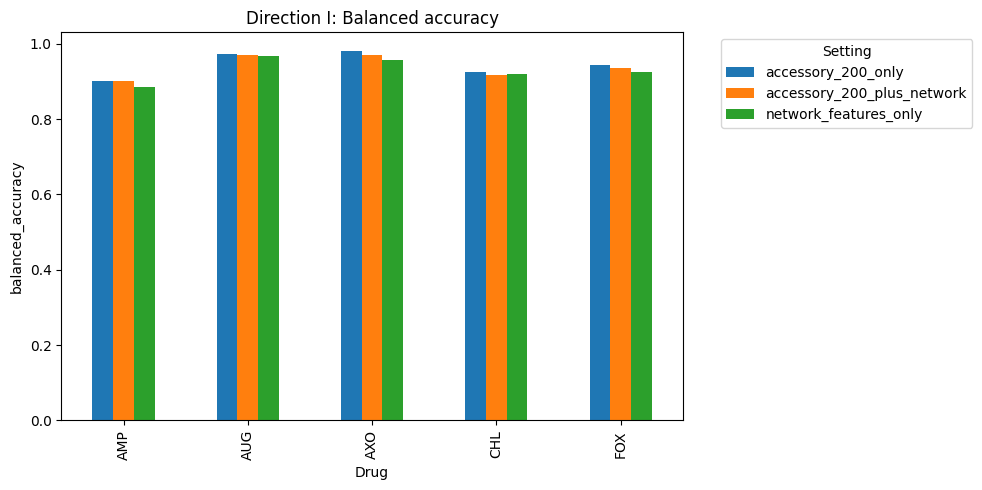

Saved: /content/salmonella_direction_I_network/outputs/direction_I_balanced_accuracy.png


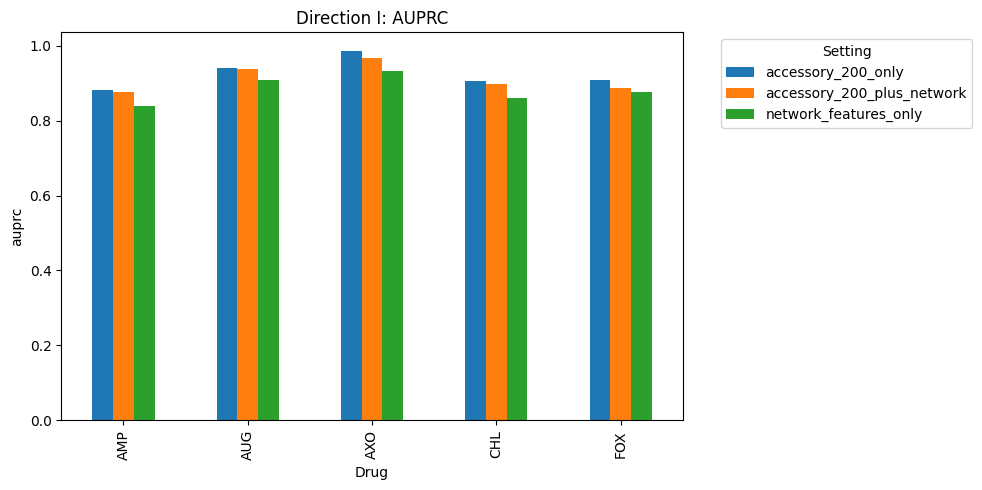

Saved: /content/salmonella_direction_I_network/outputs/direction_I_auprc.png


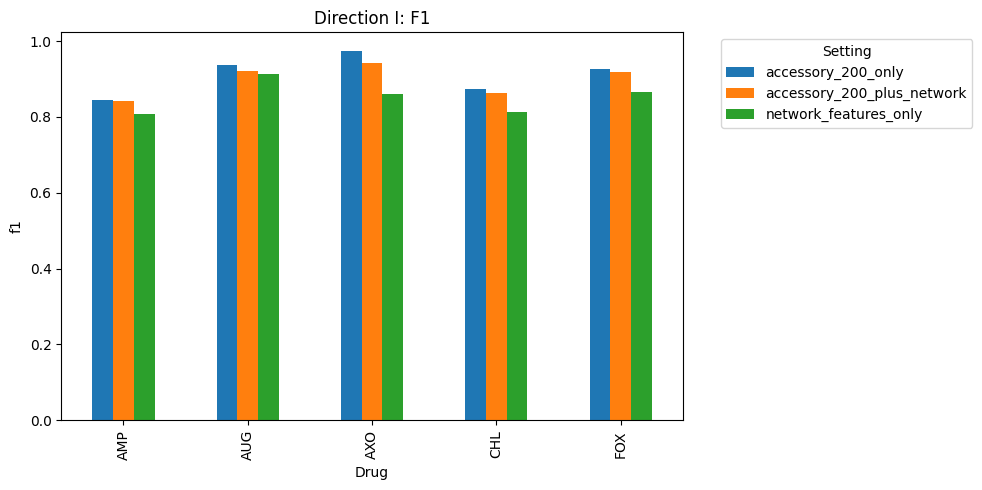

Saved: /content/salmonella_direction_I_network/outputs/direction_I_f1.png


In [10]:
# =========================
# 9. Vẽ biểu đồ
# =========================

import matplotlib.pyplot as plt

def plot_metric(metric, title, filename):
    pivot = summary_I.pivot(index="drug", columns="setting", values=f"{metric}_mean")
    ax = pivot.plot(kind="bar", figsize=(10, 5))
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_xlabel("Drug")
    ax.legend(title="Setting", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    out = OUT_DIR / filename
    plt.savefig(out, dpi=200)
    plt.show()
    print("Saved:", out)

plot_metric("balanced_accuracy", "Direction I: Balanced accuracy", "direction_I_balanced_accuracy.png")
plot_metric("auprc", "Direction I: AUPRC", "direction_I_auprc.png")
plot_metric("f1", "Direction I: F1", "direction_I_f1.png")

In [11]:
# =========================
# 10. Top stable genes và graph stats
# =========================

stable_rows = []
for drug, counter in selected_counters.items():
    for gene, count in counter.most_common(50):
        stable_rows.append({
            "drug": drug,
            "gene": gene,
            "selected_count": count,
            "selected_frequency": count / N_REPEATS
        })

stable_I = pd.DataFrame(stable_rows)
stable_I.to_csv(OUT_DIR / "direction_I_top_stable_genes.csv", index=False)

print("Top stable genes:")
safe_display(stable_I.head(30))

graph_summary = (
    graph_stats_I
    .groupby("drug")
    .agg(
        nodes_mean=("nodes", "mean"),
        edges_mean=("edges", "mean"),
        density_mean=("density", "mean"),
        components_mean=("components", "mean")
    )
    .reset_index()
)
graph_summary.to_csv(OUT_DIR / "direction_I_graph_summary.csv", index=False)
print("Graph summary:")
safe_display(graph_summary)

Top stable genes:


,drug,gene,selected_count,selected_frequency
0,AMP,group_3068,10,1.0
1,AMP,CJW30_15375,10,1.0
2,AMP,HF382_002470,10,1.0
3,AMP,GXH02_05140,10,1.0
4,AMP,DSP25_11545,10,1.0
5,AMP,K1191_004890,10,1.0
6,AMP,FMQ12_17615,10,1.0
7,AMP,C3T99_20030,10,1.0
8,AMP,GSD89_003989,10,1.0
9,AMP,EE397_06365,10,1.0


Graph summary:


,drug,nodes_mean,edges_mean,density_mean,components_mean
0,AMP,200.0,1155.3,0.058055,3.5
1,AUG,200.0,1163.6,0.058472,2.9
2,AXO,200.0,1184.4,0.059518,2.1
3,CHL,200.0,1123.3,0.056447,4.7
4,FOX,200.0,1173.5,0.058970,2.0


In [12]:
# =========================
# 11. STRING attempt cho top genes/known markers
# =========================

import requests

KNOWN_MARKERS = [
    "CMY-2", "TEM-1", "floR", "sul2", "sugE", "merT", "merA",
    "FKE51_24750", "CKP39_24515", "GXH02_05140", "HF382_002470"
]

def string_get_ids(genes, species=99287):
    # species 99287: Salmonella enterica subsp. enterica serovar Typhimurium str. LT2
    url = "https://string-db.org/api/tsv/get_string_ids"
    params = {
        "identifiers": "\r".join(genes),
        "species": species,
        "limit": 1,
        "echo_query": 1
    }
    try:
        r = requests.post(url, data=params, timeout=30)
        r.raise_for_status()
        lines = [line.split("\t") for line in r.text.strip().split("\n") if line.strip()]
        if not lines:
            return pd.DataFrame()
        header = lines[0]
        data = lines[1:]
        return pd.DataFrame(data, columns=header)
    except Exception as e:
        print("STRING get ids failed:", e)
        return pd.DataFrame()

def string_get_network(string_ids, species=99287):
    url = "https://string-db.org/api/tsv/network"
    params = {
        "identifiers": "%0d".join(string_ids),
        "species": species,
        "required_score": 400
    }
    try:
        r = requests.post(url, data=params, timeout=60)
        r.raise_for_status()
        lines = [line.split("\t") for line in r.text.strip().split("\n") if line.strip()]
        if not lines:
            return pd.DataFrame()
        header = lines[0]
        data = lines[1:]
        return pd.DataFrame(data, columns=header)
    except Exception as e:
        print("STRING network failed:", e)
        return pd.DataFrame()

# Lấy top genes ổn định từ mỗi thuốc + marker biết trước
top_genes_for_string = set(KNOWN_MARKERS)
for drug in DRUGS:
    top_genes_for_string.update(stable_I[stable_I["drug"] == drug].head(20)["gene"].tolist())

top_genes_for_string = sorted([str(g) for g in top_genes_for_string if str(g) and str(g).lower() != "nan"])
print("Số gene thử map STRING:", len(top_genes_for_string))
print(top_genes_for_string[:30])

# Thử 2 taxid: Typhimurium LT2 và Salmonella enterica broad
mapping_frames = []
for taxid in [99287, 28901]:
    print("Trying STRING species:", taxid)
    m = string_get_ids(top_genes_for_string, species=taxid)
    if not m.empty:
        m["species_try"] = taxid
        mapping_frames.append(m)
        print("Mapped rows:", len(m))
        break

if mapping_frames:
    string_mapping = pd.concat(mapping_frames, ignore_index=True)
else:
    string_mapping = pd.DataFrame()

string_mapping.to_csv(OUT_DIR / "direction_I_string_mapping_attempt.csv", index=False)
safe_display(string_mapping.head(20))

if not string_mapping.empty and "stringId" in string_mapping.columns:
    string_ids = string_mapping["stringId"].dropna().unique().tolist()[:100]
    string_network = string_get_network(string_ids, species=int(string_mapping["species_try"].iloc[0]))
else:
    string_network = pd.DataFrame()

string_network.to_csv(OUT_DIR / "direction_I_string_network_attempt.csv", index=False)
print("STRING network rows:", len(string_network))
safe_display(string_network.head(10))

Số gene thử map STRING: 72
['B5A41_24415', 'B6M27_02115', 'BW088_13565', 'C0692_20845', 'C0N02_10315', 'C2J16_23265', 'C3004_19165', 'C3009_23215', 'C3T99_20030', 'CAD01_23650', 'CAR27_22395', 'CBH71_23260', 'CBR12_24605', 'CBU12_02120', 'CEW36_07710', 'CGT24_24070', 'CJ664_25145', 'CJW30_15375', 'CJW60_09240', 'CKP39_24515', 'CKP58_25195', 'CMY-2', 'CPJ81_20550', 'CYN48_22245', 'DKF47_19030', 'DKF47_23050', 'DSP25_11545', 'DT764_24335', 'DWF11_25265', 'E2U96_19385']
Trying STRING species: 99287
Mapped rows: 1


,queryItem,queryIndex,stringId,ncbiTaxonId,taxonName,preferredName,annotation,species_try
0,sugE,70,99287.STM4338,99287,Salmonella enterica Typhimurium,sugE,Putative DMT superfamily transport protein; Gu...,99287


STRING network rows: 20


,stringId_A,stringId_B,preferredName_A,preferredName_B,ncbiTaxonId,score,nscore,fscore,pscore,ascore,escore,dscore,tscore
0,99287.STM0866,99287.STM3448,mdfA,rpsL,99287,0.507,0,0,0,0,0,0,0.507
1,99287.STM0866,99287.STM1482,mdfA,ydgF,99287,0.733,0,0,0.158,0,0,0,0.697
2,99287.STM0866,99287.STM4338,mdfA,sugE,99287,0.826,0,0,0.155,0,0,0,0.803
3,99287.STM0866,99287.STM3186,mdfA,tolC,99287,0.897,0,0,0,0.049,0,0,0.897
4,99287.STM1482,99287.STM4338,ydgF,sugE,99287,0.943,0.086,0,0.468,0,0,0,0.893
5,99287.STM3096,99287.STM4338,yqgE,sugE,99287,0.764,0,0,0,0,0,0,0.764
6,99287.STM3096,99287.STM4339,yqgE,blc,99287,0.767,0,0,0,0,0,0,0.767
7,99287.STM3096,99287.STM4341,yqgE,frdC,99287,0.89,0,0,0,0,0,0,0.89
8,99287.STM3096,99287.STM4340,yqgE,frdD,99287,0.892,0,0,0,0,0,0,0.892
9,99287.STM3186,99287.STM3448,tolC,rpsL,99287,0.467,0,0,0,0.042,0,0,0.467


In [13]:
# =========================
# 12. Kết luận tự động
# =========================

lines = []
lines.append("# Direction I — Network-guided feature augmentation")
lines.append("")
lines.append("## Mục tiêu")
lines.append("Thử bổ sung đặc trưng mạng gene-gene vào mô hình dự đoán AMR.")
lines.append("Mạng được xây từ đồng xuất hiện/tương quan của các gen phụ được chọn trên tập huấn luyện.")
lines.append("")
lines.append("## Kết quả tốt nhất theo balanced accuracy")
for _, row in best_bal.iterrows():
    lines.append(
        f"- {row['drug']}: best = {row['setting']}, "
        f"balanced accuracy = {row['balanced_accuracy_mean']:.3f} ± {row['balanced_accuracy_std']:.3f}, "
        f"AUPRC = {row['auprc_mean']:.3f} ± {row['auprc_std']:.3f}."
    )

lines.append("")
lines.append("## Diễn giải")
win_counts = best_bal["setting"].value_counts().to_dict()
lines.append(f"Số thuốc thắng theo từng setting: {win_counts}.")
lines.append("")
lines.append("Nếu `accessory_200_plus_network` thắng ở một số thuốc, điều đó gợi ý rằng network features bổ sung tín hiệu cho mô hình.")
lines.append("Nếu `accessory_chi2_200` vẫn thắng, điều đó gợi ý rằng gen phụ riêng lẻ đã chứa phần lớn tín hiệu dự đoán.")
lines.append("Nếu `network_features_only` thấp, network features chỉ nên dùng bổ sung, không thay thế gene features.")
lines.append("")
lines.append("## STRING")
if string_mapping.empty:
    lines.append("STRING mapping không map được nhiều gene, có thể do tên feature trong Roary/locus tag không khớp identifier STRING.")
else:
    lines.append(f"STRING mapping map được {len(string_mapping)} dòng. Kết quả lưu ở direction_I_string_mapping_attempt.csv.")
if string_network.empty:
    lines.append("STRING network không tạo được hoặc quá ít tương tác. Phần co-occurrence network vẫn là kết quả chính trong notebook này.")
else:
    lines.append(f"STRING network có {len(string_network)} cạnh/tương tác. Kết quả lưu ở direction_I_string_network_attempt.csv.")
lines.append("")
lines.append("## Kết luận ngắn")
lines.append("Direction I là hướng feature augmentation lấy cảm hứng từ STRING/network. Nó kiểm tra xem thêm đặc trưng mạng có tăng hiệu năng so với gen phụ 200 hay không.")

conclusion_text = "\n".join(lines)
print(conclusion_text)

with open(OUT_DIR / "AUTO_CONCLUSION_DIRECTION_I.md", "w", encoding="utf-8") as f:
    f.write(conclusion_text)

# Direction I — Network-guided feature augmentation

## Mục tiêu
Thử bổ sung đặc trưng mạng gene-gene vào mô hình dự đoán AMR.
Mạng được xây từ đồng xuất hiện/tương quan của các gen phụ được chọn trên tập huấn luyện.

## Kết quả tốt nhất theo balanced accuracy
- AMP: best = accessory_200_plus_network, balanced accuracy = 0.901 ± 0.022, AUPRC = 0.877 ± 0.025.
- AUG: best = accessory_200_only, balanced accuracy = 0.974 ± 0.013, AUPRC = 0.940 ± 0.031.
- AXO: best = accessory_200_only, balanced accuracy = 0.982 ± 0.025, AUPRC = 0.986 ± 0.028.
- CHL: best = accessory_200_only, balanced accuracy = 0.925 ± 0.036, AUPRC = 0.907 ± 0.056.
- FOX: best = accessory_200_only, balanced accuracy = 0.945 ± 0.031, AUPRC = 0.909 ± 0.054.

## Diễn giải
Số thuốc thắng theo từng setting: {'accessory_200_only': 4, 'accessory_200_plus_network': 1}.

Nếu `accessory_200_plus_network` thắng ở một số thuốc, điều đó gợi ý rằng network features bổ sung tín hiệu cho mô hình.
Nếu `accessory_chi2_200` vẫn thắng, điều 

In [14]:
# =========================
# 13. Nén kết quả
# =========================

zip_path = BASE_DIR / "salmonella_direction_I_outputs.zip"
run(f'cd "{OUT_DIR}" && zip -r "{zip_path}" .', check=False)
print("Output zip:", zip_path)

>>> cd "/content/salmonella_direction_I_network/outputs" && zip -r "/content/salmonella_direction_I_network/salmonella_direction_I_outputs.zip" .
Output zip: /content/salmonella_direction_I_network/salmonella_direction_I_outputs.zip
